In [1]:
#Code Block 1
## import libraries

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

plt.style.use('seaborn-v0_8')
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
#Code Block 2
## load the cleaned data

data_clean = pd.read_csv('../../Data/Hennepin/cleaned/cleaned_mortgage_covenant_data.csv')
display(data_clean.head())
data_clean.info()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,27037060737,Race Not Available,6,185000.0,195000.0,96.0,6.125,40.37,73.48,10,0.0,False,0
1,2023,27141030504,Race Not Available,6,375000.0,385000.0,96.0,6.625,10.64,121.26,10,0.0,False,0
2,2023,27023950400,Race Not Available,6,105000.0,105000.0,96.0,6.125,8.92,90.13,10,0.0,False,0
3,2023,27171100101,Race Not Available,6,285000.0,285000.0,96.0,6.750,13.27,104.37,10,0.0,False,0
4,2023,27159480100,Race Not Available,6,175000.0,175000.0,96.0,6.875,5.87,82.22,10,0.0,False,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       100931 non-null  object 
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     100931 non-null  float64
 6   income                             100931 non-null  float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

Analysis of Property Value vs. Covenant Density

In [5]:
#Code Block 3
## property value vs. covenant density

data_clean.groupby('covenant_density')['property_value'].describe()

,count,mean,std,min,25%,50%,75%,max
covenant_density,,,,,,,,
0,89762.0,376651.589760,1.106256e+06,5000.0,255000.0,325000.0,405000.0,111325000.0
High (101-200),1720.0,511220.930233,1.601397e+06,55000.0,315000.0,345000.0,475000.0,64405000.0
Low (1-50),4537.0,403155.168614,3.127115e+05,5000.0,275000.0,325000.0,405000.0,7625000.0
Medium (51-100),1772.0,530558.690745,1.552490e+06,55000.0,295000.0,325000.0,485000.0,48055000.0
Very High (>200),3140.0,479095.541401,4.563230e+05,25000.0,325000.0,355000.0,495000.0,14205000.0


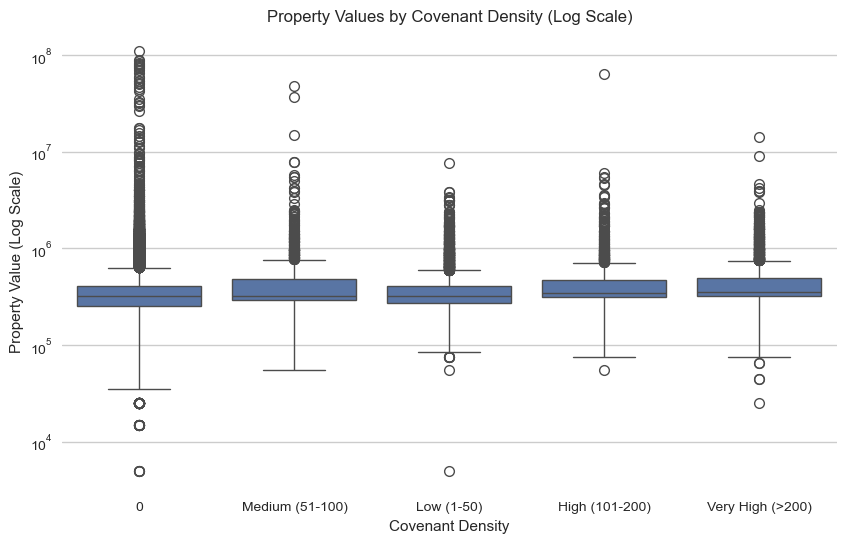

In [7]:
#Code Block 4
## visualization for property value vs. covenant density

plt.figure(figsize=(10,6))

sns.boxplot(data=data_clean, x='covenant_density', y='property_value')

plt.yscale('log')
plt.title("Property Values by Covenant Density (Log Scale)")
plt.xlabel("Covenant Density")
plt.ylabel("Property Value (Log Scale)")

plt.show()

derived_race
White               0.756063
Joint               0.744129
Asian               0.707705
Multiracial         0.659259
Native American     0.622003
Black               0.604155
Pacific Islander    0.566372
Unknown             0.405812
Name: was_approved, dtype: float64

/var/folders/mm/xkwn8c6n2djgfy47v6p2myf00000gn/T/ipykernel_2121/3635253536.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_clean, x='derived_race', y='was_approved', palette='viridis', order=data_clean.groupby('derived_race')['was_approved'].mean().sort_values(ascending=False).index)


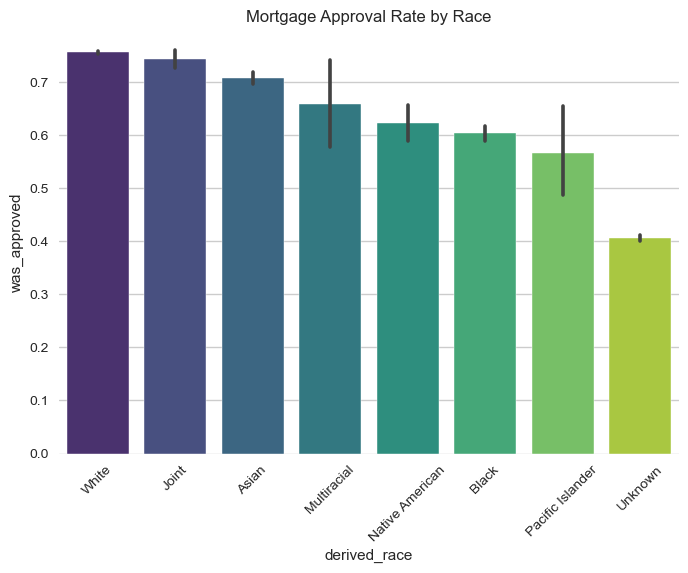

In [20]:
#Code Block 5
## approval rates grouped by derived race
race_clean_map = {
    "White": "White",
    "Black or African American": "Black",
    "Asian": "Asian",
    "American Indian or Alaska Native": "Native American",
    "Native Hawaiian or Other Pacific Islander": "Pacific Islander",
    "2 or more minority races": "Multiracial",
    "Joint": "Joint",
    "Free Form Text Only": "Unknown",
    "Race Not Available": "Unknown"
}

data_clean['derived_race'] = data_clean['derived_race'].replace(race_clean_map)

display(data_clean.groupby('derived_race')['was_approved'].mean().sort_values(ascending=False))

sns.barplot(data=data_clean, x='derived_race', y='was_approved', palette='viridis', order=data_clean.groupby('derived_race')['was_approved'].mean().sort_values(ascending=False).index)
plt.title("Mortgage Approval Rate by Race")
plt.xticks(rotation=45)
plt.show()

Detect Proxy Variables

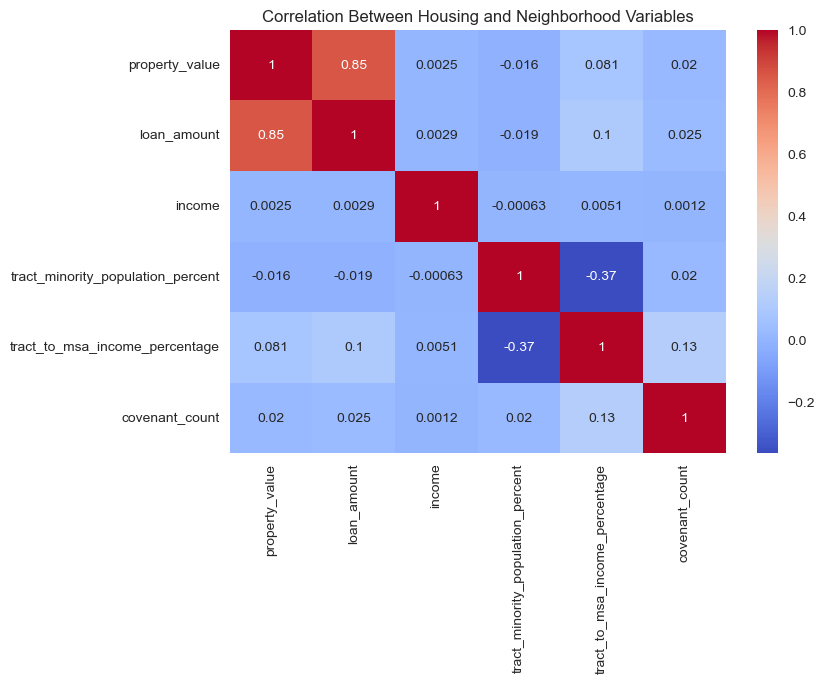

In [21]:
#Code Block 6
## correlation analysis for proxy variables

cols = [
    'property_value',
    'loan_amount',
    'income',
    'tract_minority_population_percent',
    'tract_to_msa_income_percentage',
    'covenant_count'
]

data_clean[cols].corr()

sns.heatmap(data_clean[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Housing and Neighborhood Variables")
plt.show()

Lending in Covenanted vs. Non-Covenanted Areas

has_covenants
False    0.663867
True     0.671054
Name: was_approved, dtype: float64

has_covenants
False    302042.401016
True     383043.692363
Name: loan_amount, dtype: float64

has_covenants
False    376651.589760
True     461359.566658
Name: property_value, dtype: float64

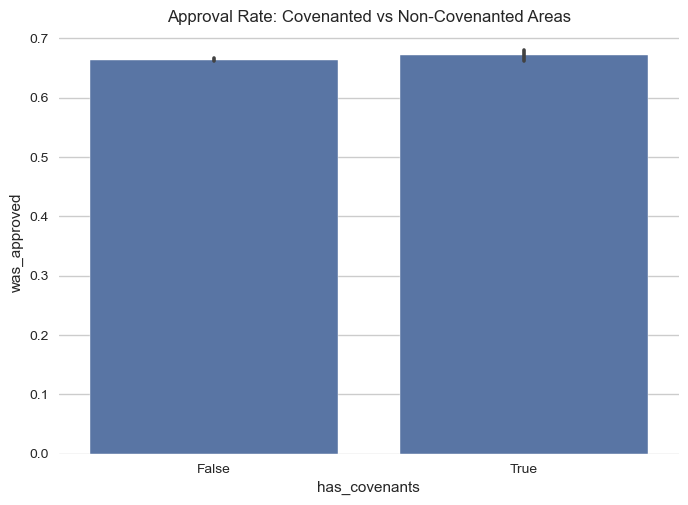

In [22]:
#Code Block 7
## compare lending in covenanted vs non-covenanted tracts

### binary variable for whether tract has any covenants
data_clean['has_covenants'] = data_clean['covenant_count'] > 0

### compare approval rates
display(data_clean.groupby('has_covenants')['was_approved'].mean())

### compare loan amounts
display(data_clean.groupby('has_covenants')['loan_amount'].mean())

### compare property values
display(data_clean.groupby('has_covenants')['property_value'].mean())

### visualize approval rates by covenant presence
sns.barplot(data=data_clean, x='has_covenants', y='was_approved')
plt.title("Approval Rate: Covenanted vs Non-Covenanted Areas")
plt.show()

In [ ]:
#Code Block 8
## pivot table for approval rates by race and covenant presence
column_order = ['0', 'Low (1-50)', 'Medium (51-100)', 'High (101-200)', 'Very High (>200)']

pivot_table = pd.pivot_table(
    data_clean,
    values='was_approved',
    index='derived_race',
    columns='covenant_density',
    aggfunc='mean'
)

pivot_table = pivot_table[column_order]
display(pivot_table)


covenant_density,0,Low (1-50),Medium (51-100),High (101-200),Very High (>200)
derived_race,,,,,
Asian,0.707331,0.689394,0.787500,0.741935,0.695652
Black,0.607475,0.578454,0.592233,0.608696,0.574257
Joint,0.738878,0.772414,0.653846,0.828125,0.806122
Multiracial,0.649573,0.571429,1.000000,0.600000,1.000000
Native American,0.622222,0.558824,0.666667,0.666667,0.666667
Pacific Islander,0.554455,0.666667,NaN,0.500000,0.750000
Unknown,0.401267,0.464029,0.405405,0.447761,0.417800
White,0.754718,0.753737,0.778605,0.773451,0.775687


Logistic Regression

In [30]:
#Code Block 9
## logistic regression prep
import statsmodels.formula.api as smf

### drop missing interest rate values
data_model = data_clean.dropna(subset=['interest_rate'])
data_model['was_approved'] = data_model['was_approved'].astype(int)

model = smf.logit(formula = """
                  was_approved ~
                  C(derived_race) +
                  income +
                  loan_amount +
                  property_value +
                  interest_rate +
                  tract_minority_population_percent +
                  tract_to_msa_income_percentage +
                  covenant_count
                  """,
        data = data_model).fit()
print(model.summary())

/var/folders/mm/xkwn8c6n2djgfy47v6p2myf00000gn/T/ipykernel_2121/3825912598.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['was_approved'] = data_model['was_approved'].astype(int)


Optimization terminated successfully.
         Current function value: 0.372902
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           was_approved   No. Observations:                78125
Model:                          Logit   Df Residuals:                    78110
Method:                           MLE   Df Model:                           14
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                  0.2633
Time:                        21:22:20   Log-Likelihood:                -29133.
converged:                       True   LL-Null:                       -39543.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               1.4270      0.096 

In [31]:
#Code Block 10
## extract odds ratios

odds_ratios = np.exp(model.params)
print(odds_ratios)

Intercept                              4.166372
C(derived_race)[T.Black]               0.524777
C(derived_race)[T.Joint]               0.848571
C(derived_race)[T.Multiracial]         1.204389
C(derived_race)[T.Native American]     0.780122
C(derived_race)[T.Pacific Islander]    0.339195
C(derived_race)[T.Unknown]             0.063863
C(derived_race)[T.White]               0.975171
income                                 1.007696
loan_amount                            0.999995
property_value                         1.000004
interest_rate                          0.998519
tract_minority_population_percent      1.000789
tract_to_msa_income_percentage         1.002060
covenant_count                         0.999725
dtype: float64


Logistic Regression for Covenant Density

In [34]:
#Code Block 11

model2 = smf.logit(
    """
    was_approved ~ 
    C(derived_race) +
    income +
    loan_amount +
    property_value +
    interest_rate +
    tract_minority_population_percent +
    tract_to_msa_income_percentage +
    C(covenant_density)
    """,
    data=data_model
).fit()

print(model2.summary())

odds_ratios = np.exp(model2.params)
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.372826
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           was_approved   No. Observations:                78125
Model:                          Logit   Df Residuals:                    78107
Method:                           MLE   Df Model:                           17
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                  0.2634
Time:                        21:50:00   Log-Likelihood:                -29127.
converged:                       True   LL-Null:                       -39543.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                   1.4040